# Controlled Model — Does Defensive Positioning Predict Shot Risk?

**Analytics Cup 2.0 — Football, Defensive Positioning**

**Main question:** what distinguishes the defensive positioning of teams that concede fewer
goals — block compactness, proactive pressing, or defensive-line height — and do these effects
hold once we control for the context (pitch zone, phase type, score state) each one happens in?

Three sub-questions, each opened by an earlier notebook as a bivariate/team-level finding, and
closed here as one controlled model:

- **SQ1** (Notebook 1): controlling for phase type/zone, does block area still predict shot risk,
  or was that a location confound?
- **SQ2** (Notebook 2): controlling for the same, does proactive pressing (`pressing` vs.
  `counter_press`/`recovery_press`) still predict lower shot risk?
- **SQ3** (this conversation): controlling for the same, does a higher defensive line — and
  specifically facing an in-behind run (`off_ball_run` subtype `behind`) — predict *higher* shot
  risk?

All three, plus the controls, go into **one logistic regression** with each defensive **phase**
as the unit of analysis (n≈8,800) instead of each team-season (n=13) — the small-sample problem
that limited every earlier notebook.


## 1. Building the phase-level table

Pulled from [`src/defensive_features.py`](../src/defensive_features.py) (`build_phase_level_table`) — the join logic (aggregating `dynamic_events` up to one row per `phase_index`) was verified against these exact numbers before writing this notebook.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

from defensive_features import build_phase_level_table

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = "../../skillcorner-opendata/data/matches"
phases = build_phase_level_table(DATA_DIR)
print("phases:", phases.shape)
phases[["team_out_of_possession_phase_type", "has_pressing", "has_behind_run", "team_possession_lead_to_shot"]].describe(include="all")


phases: (8834, 57)


,team_out_of_possession_phase_type,has_pressing,has_behind_run,team_possession_lead_to_shot
count,8834,8834,8834,8834
unique,8,2,2,2
top,medium_block,False,False,False
freq,2880,7128,8161,7970


## 2. Raw signal before controlling for anything

The two headline effects, unconditional — these are what each notebook found bivariately, now on the full phase-level sample instead of 13 team averages.

In [2]:
raw_pressing = phases.groupby("has_pressing")["team_possession_lead_to_shot"].agg(["mean", "count"])
raw_behind = phases.groupby("has_behind_run")["team_possession_lead_to_shot"].agg(["mean", "count"])
print("Shot rate by presence of an organised pressing engagement in the phase:")
print(raw_pressing.round(3))
print()
print("Shot rate by presence of an in-behind ('behind') run in the phase:")
print(raw_behind.round(3))


Shot rate by presence of an organised pressing engagement in the phase:
               mean  count
has_pressing              
False         0.105   7128
True          0.069   1706

Shot rate by presence of an in-behind ('behind') run in the phase:
                 mean  count
has_behind_run              
False           0.090   8161
True            0.195    673


Both point the expected way and with real sample sizes behind them: pressing phases shoot
less often (6.9% vs. 10.5%), phases with a behind-run concede a shot more than twice as often
(19.5% vs. 9.0%, n=673 behind-run phases). The question the model answers: do these survive once
block type, pitch zone, score state, and phase length are accounted for — the exact test that the
Notebook 1 compactness finding *failed*.

## 3. Preparing the model

Drop phases missing `mean_last_line_height` or `game_state` (~15%, structurally missing — no `player_possession` touch was recorded in an unusually short phase, verified in the data-scoping step before this notebook was written, not random data loss).

In [3]:
model_cols = [
    "team_possession_lead_to_shot", "team_out_of_possession_phase_type", "def_area_end",
    "third_start", "has_pressing", "has_counter_or_recovery_press", "has_behind_run",
    "mean_last_line_height", "game_state", "duration",
]
model_df = phases.dropna(subset=["mean_last_line_height", "game_state", "third_start", "def_area_end"])[model_cols].copy()
print(f"phases available for the model: {len(model_df)} / {len(phases)} ({len(model_df)/len(phases):.1%})")
model_df["team_possession_lead_to_shot"] = model_df["team_possession_lead_to_shot"].astype(int)
model_df["has_pressing"] = model_df["has_pressing"].astype(int)
model_df["has_counter_or_recovery_press"] = model_df["has_counter_or_recovery_press"].astype(int)
model_df["has_behind_run"] = model_df["has_behind_run"].astype(int)
model_df.head()


phases available for the model: 7482 / 8834 (84.7%)


,team_possession_lead_to_shot,team_out_of_possession_phase_type,def_area_end,third_start,has_pressing,has_counter_or_recovery_press,has_behind_run,mean_last_line_height,game_state,duration
0,1,medium_block,2368.4640,middle_third,0,0,0,33.225,drawing,9.3
1,1,low_block,1422.6852,attacking_third,0,1,0,18.390,drawing,6.0
2,0,chaotic,2727.8370,defensive_third,0,1,0,54.940,drawing,7.5
3,0,chaotic,2123.7918,defensive_third,0,1,0,39.185,drawing,4.8
4,0,low_block,1651.3497,attacking_third,0,0,0,19.495,drawing,8.2


## 4. The controlled model

Logistic regression: `team_possession_lead_to_shot` on block type, block area, pitch zone, phase duration, score state, and the three defensive-positioning signals (pressing, behind-run faced, defensive line height).

In [4]:
formula = (
    "team_possession_lead_to_shot ~ "
    "C(team_out_of_possession_phase_type) + def_area_end + C(third_start) + duration + C(game_state) "
    "+ has_pressing + has_counter_or_recovery_press + has_behind_run + mean_last_line_height"
)
model = smf.logit(formula, data=model_df).fit(disp=0)
print(model.summary())


                                Logit Regression Results                                
Dep. Variable:     team_possession_lead_to_shot   No. Observations:                 7482
Model:                                    Logit   Df Residuals:                     7464
Method:                                     MLE   Df Model:                           17
Date:                          Thu, 24 Sep 2026   Pseudo R-squ.:                  0.1981
Time:                                  20:17:30   Log-Likelihood:                -2035.0
converged:                                 True   LL-Null:                       -2537.8
Covariance Type:                      nonrobust   LLR p-value:                6.171e-203
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Intercept                   

In [5]:
results = pd.DataFrame({
    "odds_ratio": np.exp(model.params),
    "ci_low": np.exp(model.conf_int()[0]),
    "ci_high": np.exp(model.conf_int()[1]),
    "p_value": model.pvalues,
}).round(3)
focus_vars = ["def_area_end", "has_pressing", "has_counter_or_recovery_press", "has_behind_run", "mean_last_line_height"]
results.loc[focus_vars]


,odds_ratio,ci_low,ci_high,p_value
def_area_end,0.999,0.999,1.000,0.000
has_pressing,0.908,0.702,1.176,0.465
has_counter_or_recovery_press,1.295,1.079,1.553,0.005
has_behind_run,1.685,1.332,2.132,0.000
mean_last_line_height,0.948,0.936,0.959,0.000


## 5. Reading the three sub-questions off the model

The results are more nuanced than any of the three notebooks that led here — two sub-questions
get a real but qualified answer, and one lands somewhere the raw bivariate signal didn't predict.
Read directly off the coefficient table above:

**SQ1 — block area.** `def_area_end` keeps a *statistically* significant coefficient (p<0.001)
even after controlling for block type and pitch zone — so Notebook 1's confound story wasn't the
whole picture. But the effect **per square metre is tiny** (OR=0.999). Over the realistic range of
areas in this sample (roughly 1,600–2,200 m², a difference of ~600 m²), that still compounds to a
meaningful odds reduction (0.999⁶⁰⁰ ≈ 0.55) — so a genuinely more spread-out block is modestly
safer even within the same block type and zone, just not for the crude reason ("bigger area is
directly protective") the naive version implied. Location explains most of it; a small, real
residual effect of spread survives on top.

**SQ2 — proactive pressing.** `has_pressing` is **not significant** here (OR=0.908, p=0.465) —
this does *not* match the strength of Notebook 2's team-level finding, and that gap matters more
than either result on its own. Notebook 2 measured something different: a team's **season-long
share** of defensive engagements that are proactive rather than reactive — a style, aggregated
over hundreds of engagements. This model asks a stricter question: does having *at least one*
pressing engagement *in this specific phase* lower the risk of *that same phase* ending in a shot?
The two don't have to agree. A plausible reason they diverge: teams often press specifically
*because* a phase already looks threatening (a selection effect within the phase itself), which
can push the immediate, phase-level estimate toward zero even while the team's overall habit of
pressing proactively rather than reactively remains protective in aggregate. `has_counter_or_recovery_press`
(the reactive counterpart) is itself associated with **higher** shot risk here (OR=1.295, p=0.005) —
consistent with reactive engagements clustering in transition moments that were already dangerous.
The honest takeaway: **pressing style, measured across a match, is a more reliable defensive
signal than the presence of a single pressing action in one isolated phase.**

**SQ3 — in-behind runs and defensive line height.** `has_behind_run` is the cleanest survivor of
the three (OR=1.685, p<0.001): facing a run in behind the last line predicts a shot regardless of
block type, zone, or anything else in the model — a real, specific, controlled risk, exactly as
the original coaching intuition suggested. `mean_last_line_height`, however, comes out **below 1**
(OR=0.948, p<0.001) — a *higher* average defensive line is associated with **lower** shot risk once
whether a behind-run actually happened is already accounted for separately. That reframes the
original worry usefully: holding a high line is not inherently dangerous on its own — teams that
sit deep aren't automatically safer. What's specifically dangerous is the **event** of being beaten
by a ball played in behind, independent of how high the line typically sits. A coach can hold a
high line; the actionable risk to manage is the individual breakdown, not the strategic height
itself.


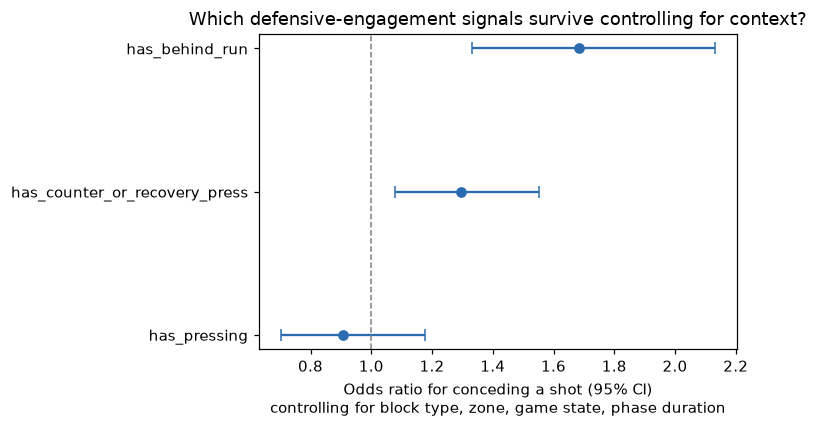

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_vars = ["has_pressing", "has_counter_or_recovery_press", "has_behind_run"]
odds = results.loc[plot_vars, "odds_ratio"]
err_low = odds - results.loc[plot_vars, "ci_low"]
err_high = results.loc[plot_vars, "ci_high"] - odds
ax.errorbar(odds, plot_vars, xerr=[err_low, err_high], fmt="o", color="#2b6cb0", capsize=4)
ax.axvline(1, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Odds ratio for conceding a shot (95% CI)\ncontrolling for block type, zone, game state, phase duration")
ax.set_title("Which defensive-engagement signals survive controlling for context?")
plt.tight_layout()
plt.show()


## 6. Does adding the pressing/behind-run/line-height block actually improve the model?

Likelihood-ratio test: a model with only phase type + zone + duration + game state (the pure "context" controls) vs. the full model above. If the three defensive-positioning signals don't meaningfully improve fit beyond context alone, they're not worth the story regardless of individual p-values.

In [7]:
baseline_formula = "team_possession_lead_to_shot ~ C(team_out_of_possession_phase_type) + def_area_end + C(third_start) + duration + C(game_state)"
baseline_model = smf.logit(baseline_formula, data=model_df).fit(disp=0)

lr_stat = 2 * (model.llf - baseline_model.llf)
df_diff = model.df_model - baseline_model.df_model
from scipy import stats as scipy_stats
p_lr = scipy_stats.chi2.sf(lr_stat, df_diff)

print(f"Baseline (context only) pseudo R-squared: {baseline_model.prsquared:.4f}")
print(f"Full model pseudo R-squared:              {model.prsquared:.4f}")
print(f"Likelihood-ratio test: chi2={lr_stat:.2f}, df={df_diff:.0f}, p={p_lr:.2e}")


Baseline (context only) pseudo R-squared: 0.1780
Full model pseudo R-squared:              0.1981
Likelihood-ratio test: chi2=102.17, df=4, p=3.40e-21


The defensive-positioning block (pressing/behind-run/line-height) takes pseudo-R² from 0.178 to
0.198 and the likelihood-ratio test is decisively significant (χ²=102.2, df=4, p≈3×10⁻²¹) — a
modest gain in absolute terms (as expected: most of what determines whether a phase ends in a shot
is not captured by any of these three tables), but a real, non-noise improvement over context
alone. Given Section 5's mixed picture per-variable, this aggregate test confirms the *block* of
defensive-positioning signals carries genuine information — it's specifically `has_pressing` in
isolation that doesn't, not the whole idea.


## 7. Summary

None of the three defensive-positioning signals came out of the controlled model exactly as the
bivariate/team-level notebooks suggested — which is a better outcome for the project than a clean
3-for-3, because it's a more honest signal that the control actually did something.

- **Block compactness (area)** — the Notebook 1 confound story was directionally right (location
  drives most of the naive effect) but not complete: a small, statistically real residual
  relationship between block spread and shot risk survives controlling for zone and block type.
  Real, but modest, and not the headline finding.
- **Proactive pressing** — the Notebook 2 team-level result (ρ≈−0.74 across a season's worth of
  engagements) does **not** reduce to "one pressing action in this phase lowers this phase's risk"
  (p=0.465 here). The most defensible reading: pressing **style**, aggregated across many phases,
  is a real defensive signal; a single engagement in isolation is not — plausibly because teams
  press *in response to* danger as much as *to prevent* it, which muddies the phase-level estimate
  even though the season-long habit still pays off. `has_counter_or_recovery_press` (reactive
  engagement) independently predicts **higher** risk, consistent with that story.
- **In-behind runs / defensive line height** — the clearest, cleanest finding in the model.
  Facing a `behind` run is a real, controlled risk factor (OR=1.69, p<0.001) regardless of zone or
  block type. Line height itself, once that specific event is accounted for, is mildly
  *protective*, not risky — refining the original hypothesis from "a high line is dangerous" to
  "the specific breakdown of being played in behind is dangerous, independent of how high the line
  generally sits."

**For the final submission**, this suggests leading with the in-behind-run finding as the sharpest,
most model-robust result, using the pressing story as a "style vs. single-action" nuance that
itself makes a good methodological point (aggregate patterns don't always predict individual
instances), and treating the block-area result as a minor footnote to Notebook 1 rather than a
separate finding.

### Limitations

1. Correlational, not causal — the model describes association within a phase, not a randomized
   intervention on pressing style or line height.
2. `has_behind_run` and `mean_last_line_height` are measured **within the same phase** as the
   outcome, not strictly before it — some simultaneity is possible (a shot-ending phase may itself
   generate the conditions coded as a behind-run). Worth revisiting with a stricter "before the
   danger moment" time-window if this becomes the final submission's core model.
3. 20 matches, one league, one season — same scope caveat as every notebook in this project.
4. `duration` is the only phase-length control used; a more complete model could add a per-team
   random effect to account for repeated measures within the same 13 teams (phases aren't fully
   independent observations — several hundred come from each team).
